**🔹 STEP 1 — Install Required Libraries**

In [ ]:
! pip install numpy matplotlib librosa scipy kagglehub

**🔹 STEP 2 — Download and Locate Audio Files**

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("pavanelisetty/sample-audio-files-for-speech-recognition")
print("Path to dataset files:", path)

# List .wav files
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".wav"):
            print(os.path.join(root, file))

Using Colab cache for faster access to the 'sample-audio-files-for-speech-recognition' dataset.
Path to dataset files: /kaggle/input/sample-audio-files-for-speech-recognition
/kaggle/input/sample-audio-files-for-speech-recognition/harvard.wav
/kaggle/input/sample-audio-files-for-speech-recognition/jackhammer.wav


**Audio path**

In [ ]:
audio_path = "/root/.cache/kagglehub/datasets/pavanelisetty/sample-audio-files-for-speech-recognition/versions/1/jackhammer.wav"

**🔹 STEP 3 — Load the Audio Signal**

In [ ]:
import librosa
import numpy as np

audio_path = "/kaggle/input/sample-audio-files-for-speech-recognition/jackhammer.wav"
signal, sr = librosa.load(audio_path, sr=None)
#signal → a NumPy array containing the audio waveform (amplitude values).
#sr → sampling rate (samples per second).
#sr=None → keeps the original sampling rate (no resampling).
print("Sampling Rate:", sr)
print("Duration:", len(signal)/sr, "seconds")
# len(signal)/sr = total number of samples.

Sampling Rate: 44100
Duration: 3.3467120181405896 seconds


**🔹 STEP 4 — Play Audio**

In [ ]:
from IPython.display import Audio
Audio(signal, rate=sr)

**🔹 STEP 5 — Plot Original Waveform**

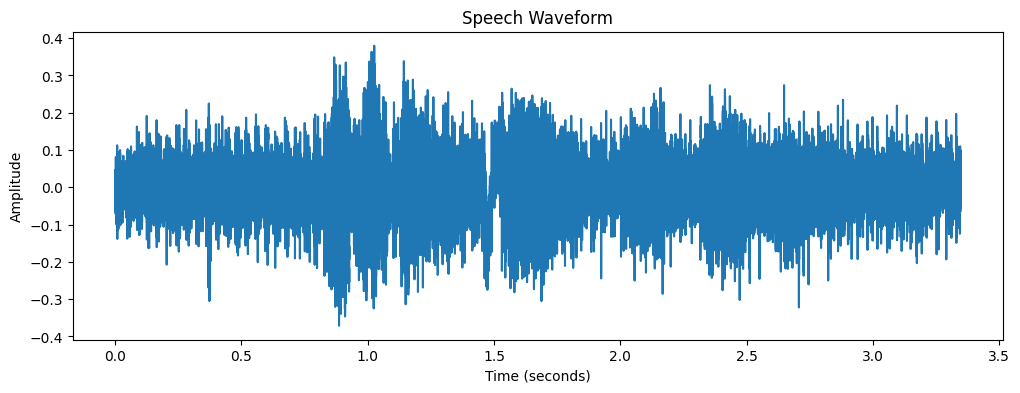

In [ ]:
import matplotlib.pyplot as plt

time = np.linspace(0, len(signal)/sr, len(signal))
#Creates a time axis for the audio signal.
#len(signal) → total number of samples
#sr → sampling rate (samples per second)
#len(signal)/sr → total duration in seconds

plt.figure(figsize=(12,4))
plt.plot(time, signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Waveform")
plt.show()

**🔹 STEP 6 — Extract Intensity (Loudness - RMS)**

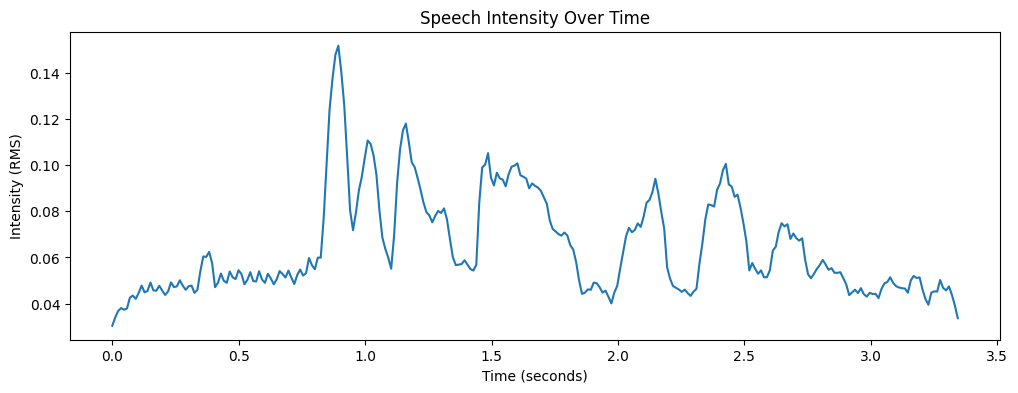

In [ ]:
rms = librosa.feature.rms(y=signal)[0]
#rms → loudness per short window
times = librosa.frames_to_time(range(len(rms)), sr=sr)
#Converts frame indices → time in seconds.

plt.figure(figsize=(12,4))
plt.plot(times, rms)
plt.xlabel("Time (seconds)")
plt.ylabel("Intensity (RMS)")
plt.title("Speech Intensity Over Time")
plt.show()

**🔹 STEP 7 — Compute FFT (Frequency Spectrum)**

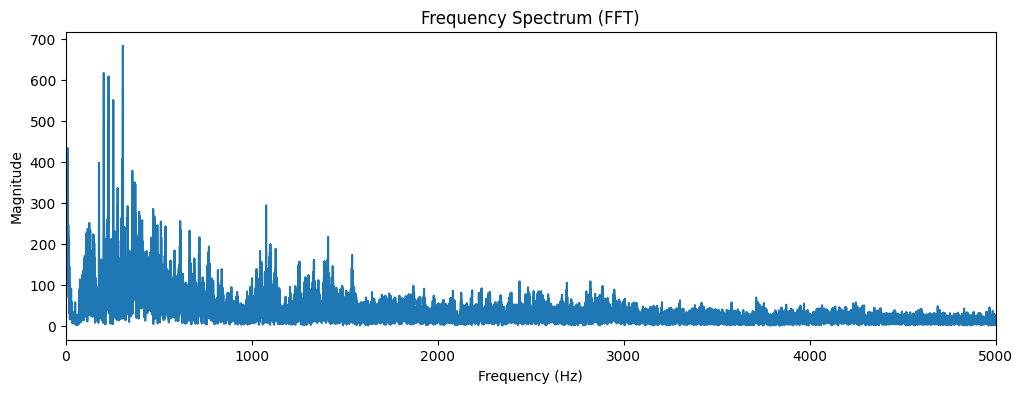

In [ ]:
from scipy.fft import fft, fftfreq

N = len(signal)
#N = total number of samples.
yf = fft(signal)
#yf = complex values #yf → frequency content
#Each value represents: Frequency component, Amplitude, Phase

xf = fftfreq(N, 1/sr)
#N → number of samples
#1/sr → sampling interval (time between samples)
#xf contains frequency values in Hz. #xf → frequency values

plt.figure(figsize=(12,4))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum (FFT)")
plt.xlim(0, 5000)
plt.show()

#FFT (Fast Fourier Transform) is an efficient algorithm that converts a signal from the time domain → frequency domain.

**🔹 STEP 8 — Plot Dominant Sinusoidal Component**

Dominant Frequency: 307.76475370960094 Hz


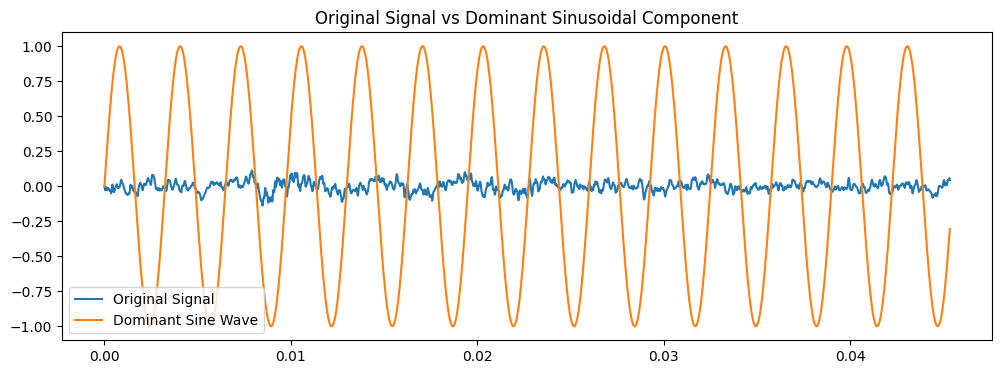

In [ ]:
spectrum = np.abs(yf[:N//2])
dominant_freq = xf[:N//2][np.argmax(spectrum)]
#np.argmax(spectrum) → index of the largest value in spectrum.

print("Dominant Frequency:", dominant_freq, "Hz")

sine_wave = np.sin(2 * np.pi * dominant_freq * time)
#Generate a sine wave at that frequency
#2 * np.pi converts cycles to radians

plt.figure(figsize=(12,4))
plt.plot(time[:2000], signal[:2000], label="Original Signal")
#Plot first 2000 samples of original signal
plt.plot(time[:2000], sine_wave[:2000], label="Dominant Sine Wave")
plt.legend()
plt.title("Original Signal vs Dominant Sinusoidal Component")
plt.show()

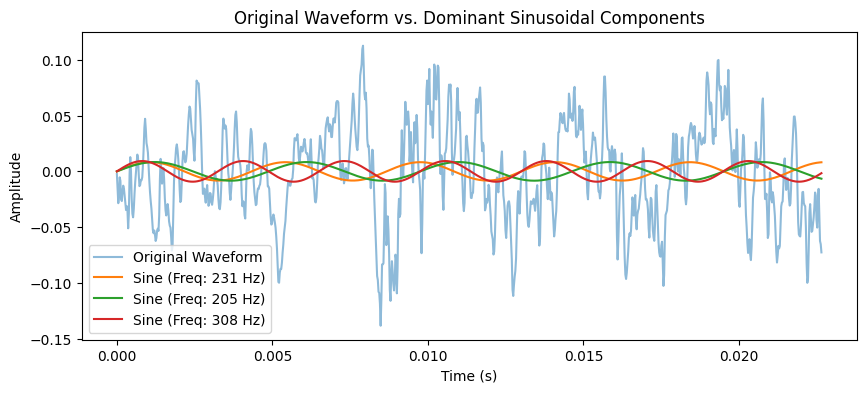

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Add this to STEP 6 to plot the top 3 sinusoidal components

N = len(signal) # Number of samples
yf = np.fft.fft(signal) # Compute FFT
#yf= frequency output
xf = fftfreq(N, 1/sr) # Generate frequency values

top_indices = np.argsort(np.abs(yf[:N//2]))[-3:] # Top 3 frequencies
top_freqs = xf[top_indices]
top_amps = np.abs(yf[:N//2])[top_indices] / (N/2)

plt.figure(figsize=(10, 4))
plt.plot(time[:1000], signal[:1000], label="Original Waveform", alpha=0.5) # plot a small segment

for i, f in enumerate(top_freqs):
    # Generate the sine wave for this component
    sine_wave = top_amps[i] * np.sin(2 * np.pi * f * time[:1000])
    plt.plot(time[:1000], sine_wave, label=f"Sine (Freq: {f:.0f} Hz)")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original Waveform vs. Dominant Sinusoidal Components")
plt.legend()
plt.show()

**🔹 STEP 9 — Extract Fundamental Frequency (Pitch F0)**

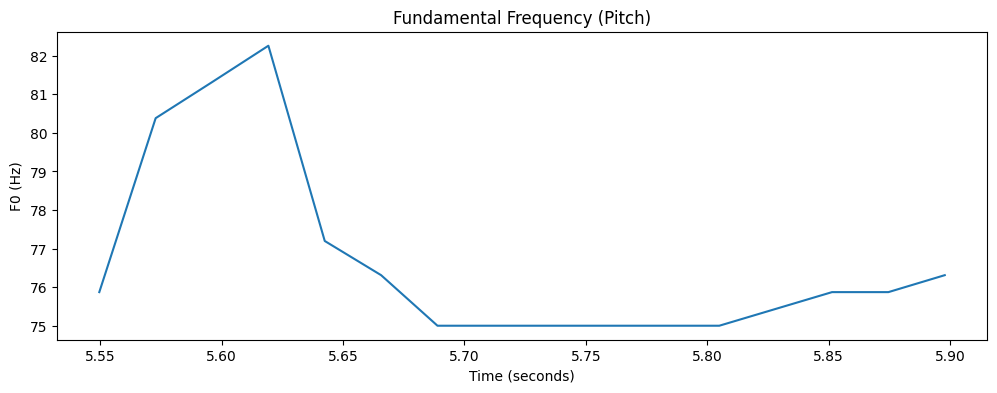

In [ ]:
f0, voiced_flag, voiced_probs = librosa.pyin(
    signal,
    fmin=75,
    fmax=300,
    sr=sr
)

times_f0 = librosa.times_like(f0)

plt.figure(figsize=(12,4))
plt.plot(times_f0, f0)
plt.xlabel("Time (seconds)")
plt.ylabel("F0 (Hz)")
plt.title("Fundamental Frequency (Pitch)")
plt.show()

**🔹 STEP 10 — Generate Spectrogram (STFT)**

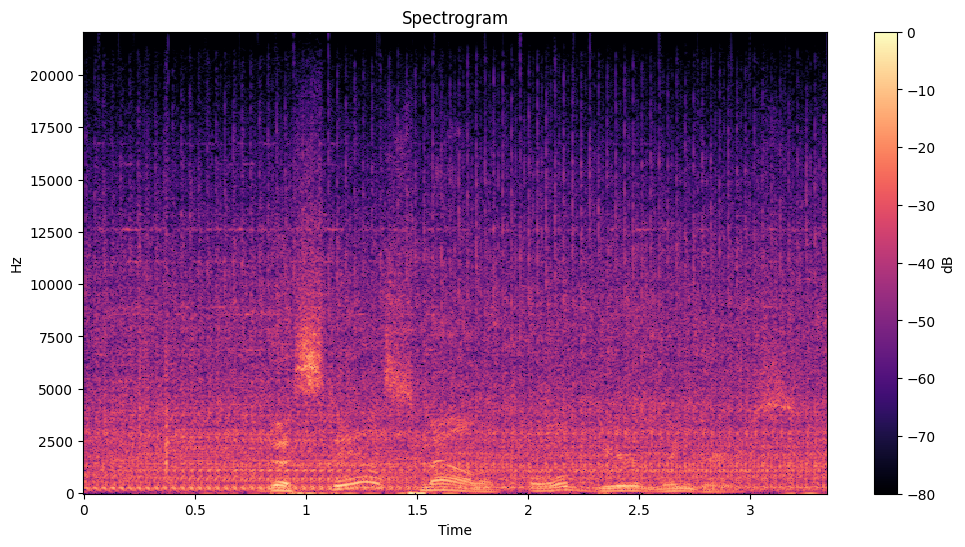

In [ ]:
import librosa.display

D = librosa.stft(signal, n_fft=1024, hop_length=256)
#D → complex 2D array: Rows → frequency bins, Columns → time frames
#signal → input audio signal
#n_fft=1024 → window size (number of samples per FFT)
#hop_length=256 → step size between successive frames
#Smaller hop length → better time resolution,  more overlap


S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
#ref=np.max → normalizes dB values relative to maximum amplitude
#0 dB = strongest signal

plt.figure(figsize=(12,6))
librosa.display.specshow(S_db, sr=sr, hop_length=256,
                         x_axis='time', y_axis='hz')
plt.colorbar(label='dB')
plt.title("Spectrogram")
plt.show()

**🔹 STEP 11 — Add Word Labels Under Spectrogram**

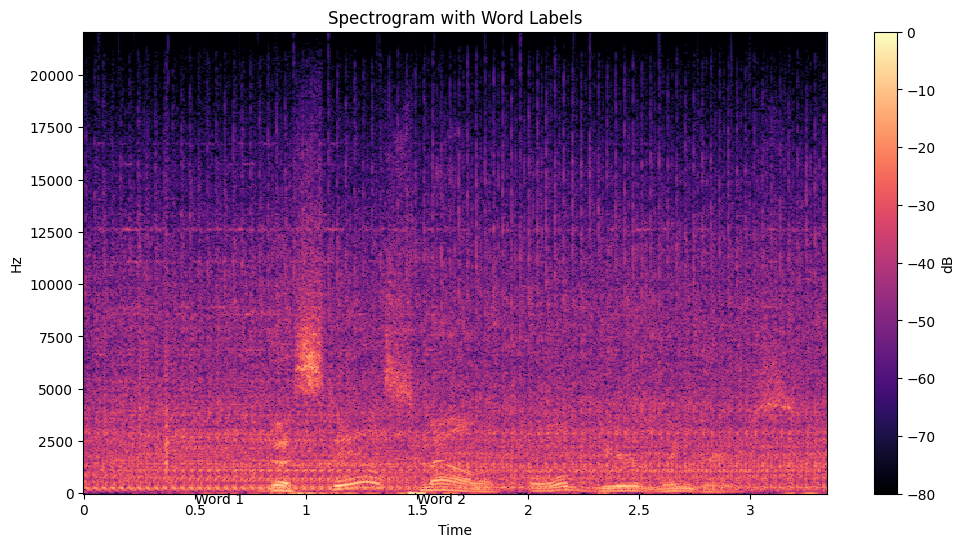

In [ ]:
plt.figure(figsize=(12,6))
librosa.display.specshow(S_db, sr=sr, hop_length=256,
                         x_axis='time', y_axis='hz')
plt.text(0.5, -500, "Word 1")
plt.text(1.5, -500, "Word 2")
plt.colorbar(label='dB')
plt.title("Spectrogram with Word Labels")
plt.show()




**🔹 STEP 12 — Compare Different Window Sizes**

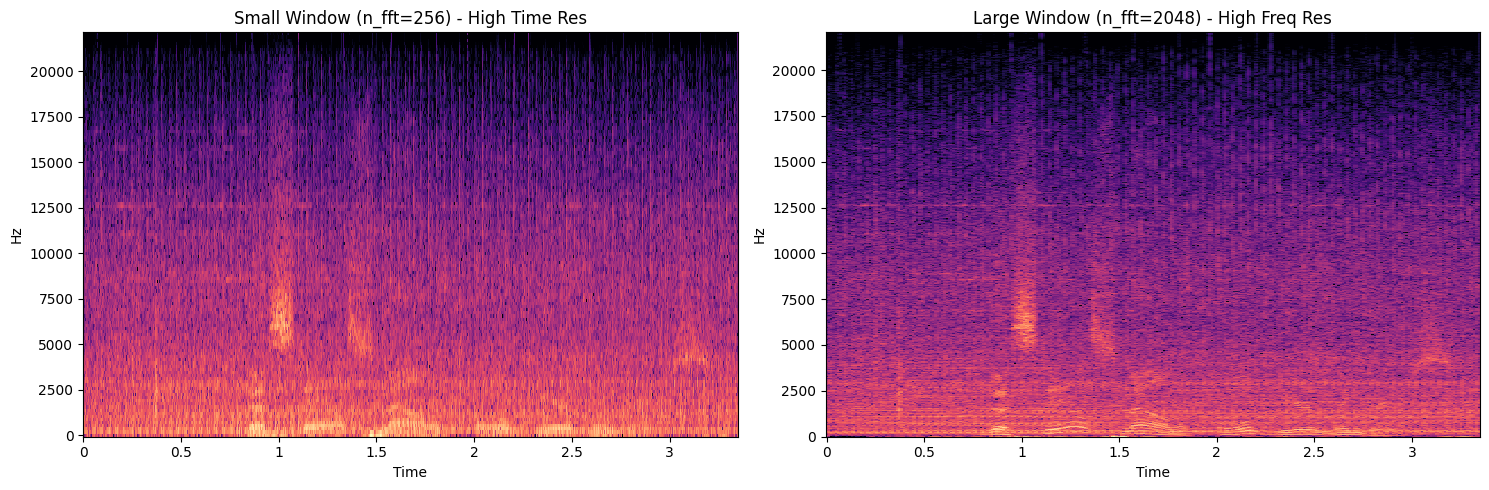

In [ ]:
# Replace STEP 10 with this to actually plot and compare them
plt.figure(figsize=(15, 5))

# Plot 1: Small Window (Good Time Resolution, Poor Frequency Resolution)
plt.subplot(1, 2, 1)
D_small = librosa.stft(signal, n_fft=256, hop_length=64) # smaller overlap
#n_fft: the number of samples used for each FFT. (window size)
#hop_length: the number of samples the window moves forward (step size)
S_small_db = librosa.amplitude_to_db(np.abs(D_small), ref=np.max)
librosa.display.specshow(S_small_db, sr=sr, hop_length=64, x_axis='time', y_axis='hz')
plt.title("Small Window (n_fft=256) - High Time Res")

# Plot 2: Large Window (Poor Time Resolution, Good Frequency Resolution)
plt.subplot(1, 2, 2)
D_large = librosa.stft(signal, n_fft=2048, hop_length=512) # larger overlap
S_large_db = librosa.amplitude_to_db(np.abs(D_large), ref=np.max)
librosa.display.specshow(S_large_db, sr=sr, hop_length=512, x_axis='time', y_axis='hz')
plt.title("Large Window (n_fft=2048) - High Freq Res")

plt.tight_layout()
plt.show()
## Small Window (Better Time Resolution)
## Large Window (Better Frequency Resolution)

Small Window (Left): Gives High Time Resolution. It’s great at showing exactly when a sound starts and stops (sharp vertical lines), but the pitch (horizontal lines) is blurry.

Large Window (Right): Gives High Frequency Resolution. it’s great at showing the exact pitch or harmonics (clear horizontal lines), but the timing of when things happen is blurry.

**🔹 STEP 13 — Segment-Based Dominant Frequency Analysis**

In [ ]:
segment_length = sr  # 1 second segment
#segment_length = number of samples per segment.
#sr = sampling rate (samples per second).

for i in range(0, len(signal), segment_length):
  #Loop over the signal in steps of 1 second
    segment = signal[i:i+segment_length]
    if len(segment) == segment_length:
      #Ensures the last segment is full 1 second
        yf_seg = fft(segment)
        #Compute FFT of this segment → FFT OUTPUT.
        xf_seg = fftfreq(segment_length, 1/sr)
        #Generate frequency values corresponding to the FFT of the segment.
        spectrum_seg = np.abs(yf_seg[:segment_length//2])
        #Take magnitude of FFT for positive frequencies only.
        dom_freq = xf_seg[:segment_length//2][np.argmax(spectrum_seg)]
        #Find index of maximum amplitude
        print(f"Segment {i//sr + 1} Dominant Frequency: {dom_freq:.2f} Hz")

Segment 1 Dominant Frequency: 230.00 Hz
Segment 2 Dominant Frequency: 10.00 Hz
Segment 3 Dominant Frequency: 370.00 Hz


(1)segment length = 1 second (samples = sr).

(2)Loop through the signal in 1-second steps.

(3)Extract current 1-second segment.

(4)Skip the segment if it’s shorter than 1 second.

(5)Compute FFT of the segment.

(6)Generate frequency values for the segment.

(7)Take magnitude of positive frequencies.

(8)Find the frequency with the maximum amplitude → dominant frequency.

(9)Print the dominant frequency for the current segment.